In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки
import matplotlib.pyplot as plt


In [2]:
# Ячейка № 2

# задание функции, возвращающей
# значения прямоугольного двухполярного импульса
def FF(t, T):
    # определение числа узлов временной сетки
    N = len(t)

    # инициализация массива, используемого
    # для хранения значений
    # прямоугольного двухполярного импульса
    z = np.zeros(N)

    # вычисление значений двухполярного
    # прямоугольного импульса в
    # узлах временной сетки
    for i in range(N):
        if t[i] < 0:
            z[i] = 0
        if (t[i] >= 0) & (t[i] <= T / 2):
            z[i] = 0.5
        if (t[i] > T / 2) & (t[i] <= T):
            z[i] = -0.5
        if t[i] > T:
            z[i] = 0
    return z

In [ ]:
# Ячейка № 3

# задание функции, возвращающей
# численные значения коэффициентов ряда Фурье,
# вычисленные в соответствие с (7.9)
def AF(k, F):
    # определение числа узлов временной сетки
    N = len(t)

    # инициализация массива z
    z = np.zeros(N)

    # вычисление шага временной сетки
    dt = t[1] - t[0]

    # вычисление значений коэффициентов
    # ряда Фурье в соответствие с (7.9)
    z = F * np.cos(2 * np.pi * k / T * t)

    return (2 / T) * np.trapz(z, t, dt)

In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# численные значения коэффициентов ряда Фурье,
# вычисленные в соответствие с (7.10)


def BF(k, F):
    # определение числа узлов временной сетки
    N = len(t)

    # инициализация массива z
    z = np.zeros(N)

    # вычисление шага временной сетки
    dt = t[1] - t[0]

    # вычисление значений коэффициентов
    # ряда Фурье в соответствие с (7.9)
    z = F * np.sin(2 * np.pi * k / T * t)

    return (2 / T) * np.trapz(z, t, dt)

In [5]:
# Ячейка № 5

# задание длительности импульса
T = 1

# задание числа узлов временной сетки
N = 1000

# задание координаты узлов временной сетки
t = np.linspace(0, T, N)

F = FF(t, T)
# вычисление коэффициента A0 в
# соответствие с (7.8)
A0 = AF(0, F)

# задание числа гармоник с учетом
# гармоники с нулевой частотой
Nf = 20

# инициализация массивов A, B,
# используемых для хранения коэффициентов ряда Фурье
A = np.zeros(Nf - 1)
B = np.zeros(Nf - 1)

# вычисление коэффициентов ряда Фурье

for k in range(Nf - 1):
    A[k] = AF(k + 1, F)
    B[k] = BF(k + 1, F)

# инициализация  массива s,
# используемого для хранения значений
# частичной суммы ряда Фурье
s = np.zeros(N)

# вычисление частичной сумм ряда Фурье
for i in range(N):
    S = A0 / 2
    for k in range(Nf - 1):
        S = (
            S
            + A[k] * np.cos(2 * np.pi * (k + 1) / T * t[i])
            + B[k] * np.sin(2 * np.pi * (k + 1) / T * t[i])
        )

    s[i] = S

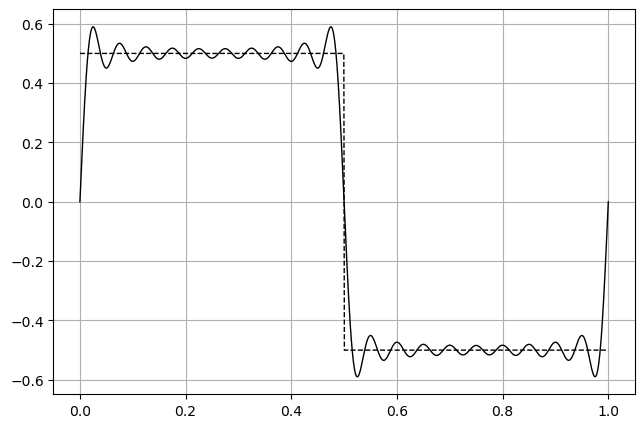

In [6]:
# Ячейка № 6

# визуализация двухполярного импульса и
# частичной суммы ряда Фурье

fig = plt.figure(figsize=(7.5, 5))
ax = fig.add_subplot()
plt.plot(t, s, "-k", lw=1)
plt.plot(t, F, "--k", lw=1)
plt.grid(True)

plt.show()